# Extended Data Fig. 7 |  Global trends in mangrove degradation and loss rates (1980s-2023)

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
import palettable
from tqdm import tqdm
import geopandas as gpd
import cartopy.crs as ccrs
import ZhenPlot
from geemap import cartoee as cee
import geemap

plt.rcParams['font.sans-serif'] = ['Arial']
%config InlineBackend.figure_format = 'retina'

In [ ]:
def trend(series):
    series=100*series
    au, p_value = stats.kendalltau(series, series.index) #Calculate the Kendall's tau and p-value
    slope = stats.mstats.theilslopes(series, series.index)#Calculate the TS slope and transfer the unit to %
    return slope[0]

os.chdir(r'D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\code')
df_deforestation_annualrate = pd.read_csv('Code_Data/EstimatedAnnualChange/ByGrid_AnnualDeforestationRate_XGBoost.csv')
df_degradation_annualrate = pd.read_csv('Code_Data/EstimatedAnnualChange/ByGrid_AnnualDegradationRate_XGBoost.csv')

variable = 'trend'
df_deforestation_annualrate[variable] = df_deforestation_annualrate[[str(i) for i in range(1984,2023)]].apply(trend, axis=1)
df_degradation_annualrate[variable] = df_degradation_annualrate[[str(i) for i in range(1984,2023)]].apply(trend, axis=1)

gdf_grids = gpd.read_file('Code_Data/Grids_1degree.shp') # Read the grid shapefile
gdf_grids = gdf_grids[['ID','geometry']] # Select the columns we need
gdf_degradation = gdf_grids.merge(df_degradation_annualrate, left_on='ID', right_on='Region', how='left') # Join the degradation rate with the grid shapefile by the grid ID
gdf_degradation = gdf_degradation[gdf_degradation['ID'].isin(df_degradation_annualrate['Region'])] # Filter the grids which have degradation data

gdf_deforestation = gdf_grids.merge(df_deforestation_annualrate, left_on='ID', right_on='Region', how='left') # Join the deforestation rate with the grid shapefile by the grid ID
gdf_deforestation = gdf_deforestation[gdf_deforestation['ID'].isin(df_deforestation_annualrate['Region'])] # Filter the grids which have degradation data
gdf_deforestation.head(5)

,ID,geometry,Region,1984,1985,1986,1987,1988,1989,1990,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,trend
1,1,"POLYGON ((147 -39, 147.0625 -39, 147.125 -39, ...",1.0,0.001325,0.001325,0.001325,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,"POLYGON ((173 -40, 173 -39, 173.0625 -39, 173....",2.0,0.006579,0.006579,0.006579,0.006579,0.006579,0.0,0.0,...,0.000000,0.199885,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,5,"POLYGON ((176 -40, 176 -39, 176.0625 -39, 176....",5.0,0.012285,0.012285,0.012285,0.012285,0.012285,0.0,0.0,...,0.000000,0.000000,0.235294,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,6,"POLYGON ((177 -40, 177 -39, 177.0625 -39, 177....",6.0,0.006589,0.006589,0.006589,0.006589,0.006589,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,9,"POLYGON ((144 -39, 144 -38, 144.0625 -38, 144....",9.0,0.000081,0.000081,0.000000,0.000000,0.000000,0.0,0.0,...,0.010361,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


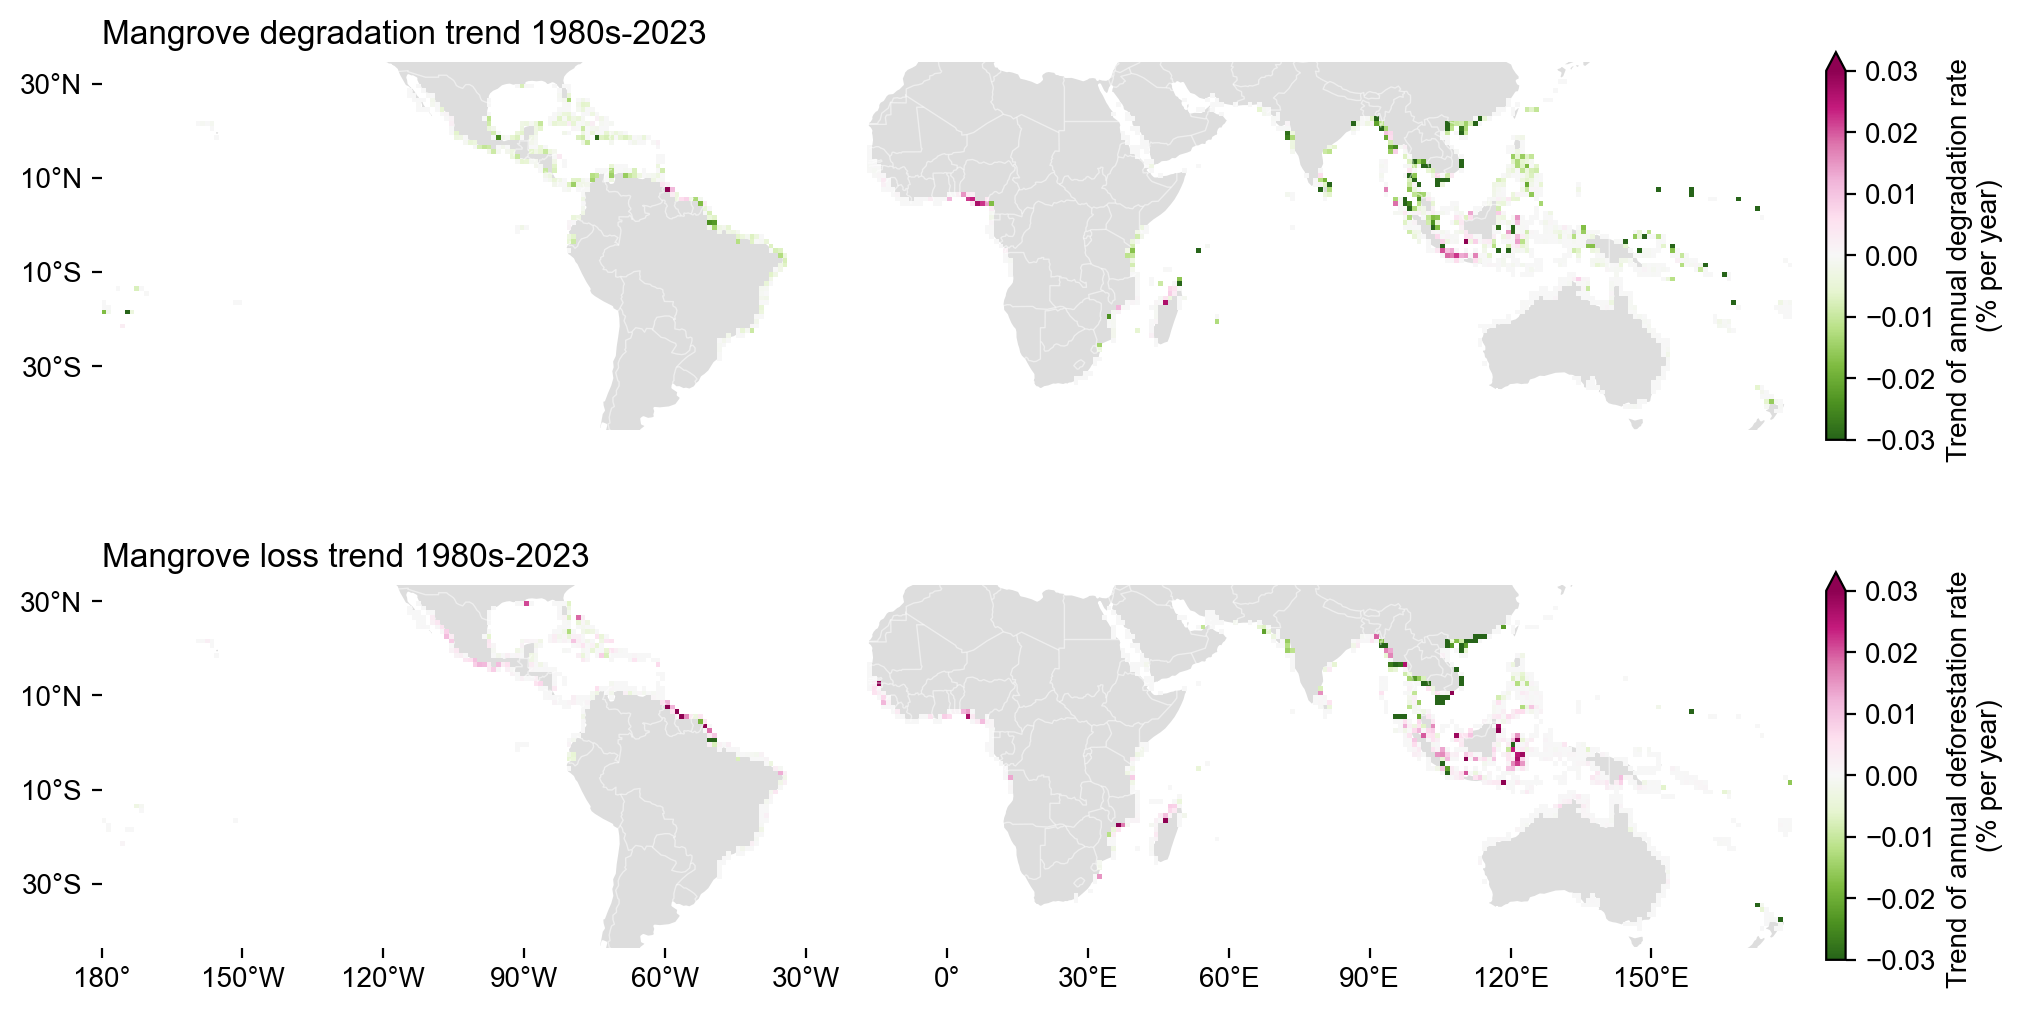

In [ ]:
fig = plt.figure(figsize=(10,5.2),constrained_layout=True)
gs = GridSpec(nrows=2, ncols=1,figure=fig)

ax_a = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax_b = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
axs = [ax_a,ax_b]
gdfs = [gdf_degradation,gdf_deforestation]
titles = ['Mangrove degradation trend 1980s-2023','Mangrove loss trend 1980s-2023']
cb_labels = ["Trend of annual degradation rate \n(% per year)","Trend of annual deforestation rate \n(% per year)"]
for i,ax in enumerate(axs):
    ZhenPlot.add_basemap(ax,xticks=i,yticks=1,xrange=np.arange(-180,180,30),fontsize=12)
    ax.text(0,1.05,titles[i],fontdict={'size' : 12},color='black', transform=ax.transAxes)
    gdfs[i].plot(column=variable, ax=ax, cmap='PiYG_r',edgecolor='None', legend=True, vmax=0.03,vmin=-0.03,
              legend_kwds={'label': cb_labels[i],'orientation': "vertical",'extend':'max','shrink':0.77,'pad':0.02})
    ax.tick_params(axis='x',labelsize=10);ax.tick_params(axis='y',labelsize=10)
    ax.set_frame_on(False)

plt.savefig("Figures/LossTrend1984-2023.svg", dpi=500, format='svg', bbox_inches='tight')
plt.savefig("Figures/LossTrend1984-2023.png", dpi=500, format='png', bbox_inches='tight')